In [1]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

import nltk

In [50]:
# Download the NLTK resources required for tokenization and stopword removal.

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /Users/kct/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/kct/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/kct/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/kct/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/kct/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [51]:
# Load the 150,000-row balanced dataset created in Notebook 1.

input_path = "../data/processed/yelp_balanced_150k.csv"

df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)

Dataset shape: (150000, 3)


In [52]:
df.dtypes

class_index    int64
review_text      str
sentiment        str
dtype: object

In [53]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
class_index    0
review_text    0
sentiment      0
dtype: int64


In [54]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [55]:
# Remove duplicate reviews to avoid giving repeated examples
# to the machine learning models.

df = df.drop_duplicates(
    subset=["review_text"]
).reset_index(drop=True)

print("Dataset shape after removing duplicate reviews:", df.shape)

Dataset shape after removing duplicate reviews: (150000, 3)


In [56]:
# Check the number of reviews in each sentiment class.

sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
Neutral     50000
Negative    50000
Positive    50000
Name: count, dtype: int64


In [57]:
# Check the number of reviews in each sentiment class.

sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
Neutral     50000
Negative    50000
Positive    50000
Name: count, dtype: int64


In [58]:
# Calculate the number of characters in each review.

df["review_length"] = df["review_text"].str.len()

df[["review_text", "review_length"]].head()

,review_text,review_length
0,"Suprisingly decent, nothing spectacular but pr...",201
1,I dont wish to be a KILLJOY...but I wanted to ...,2187
2,Do yourself a favor and go try this place. You...,221
3,As the reviews of Casbah appear to be particul...,191
4,Ah Golden Wok...this place has never dissapoin...,1080


In [59]:
# Count the approximate number of words in each review.

df["word_count"] = df["review_text"].str.split().str.len()

df[["review_text", "word_count"]].head()


,review_text,word_count
0,"Suprisingly decent, nothing spectacular but pr...",36
1,I dont wish to be a KILLJOY...but I wanted to ...,391
2,Do yourself a favor and go try this place. You...,42
3,As the reviews of Casbah appear to be particul...,27
4,Ah Golden Wok...this place has never dissapoin...,201


In [60]:
df[["review_length", "word_count"]].describe()

,review_length,word_count
count,150000.000000,150000.000000
mean,718.772160,131.823960
std,668.756545,122.618734
min,1.000000,1.000000
25%,275.000000,50.000000
50%,519.000000,96.000000
75%,933.000000,172.000000
max,5115.000000,1009.000000


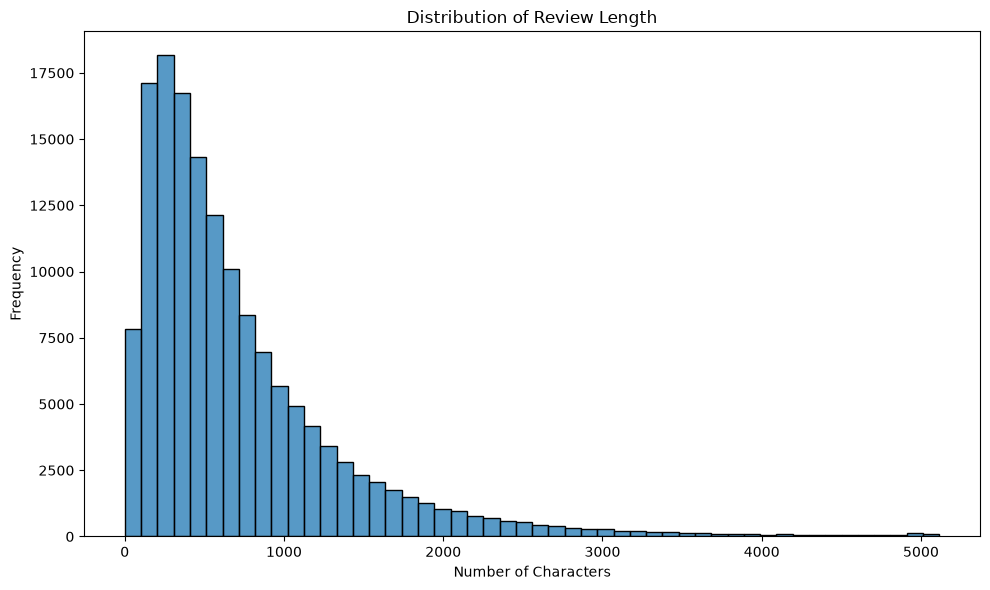

In [61]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="review_length",
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/review_length_distribution.png",
    dpi=300
)

plt.show()

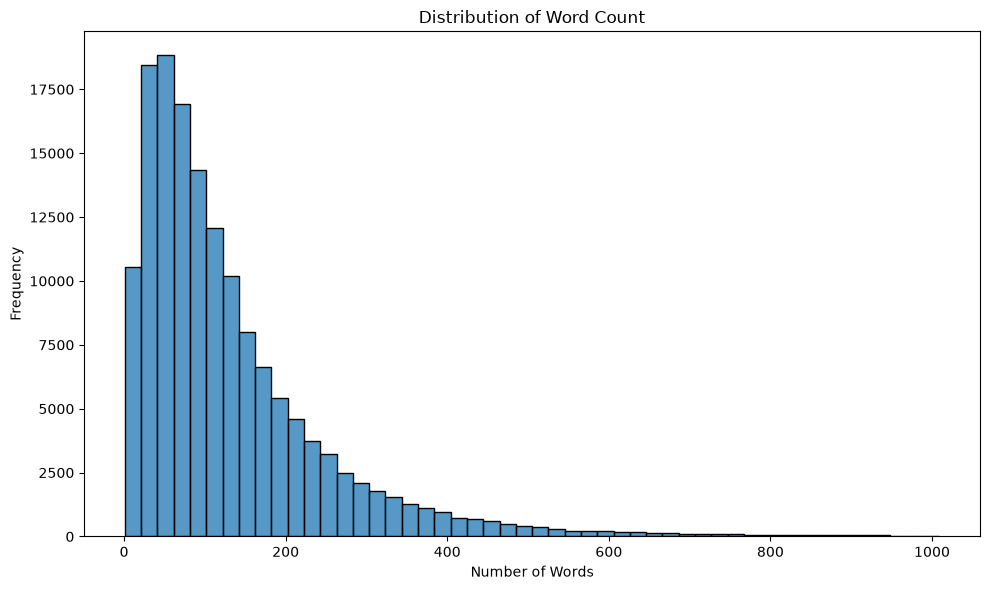

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    bins=50
)

plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/word_count_distribution.png",
    dpi=300
)

plt.show()

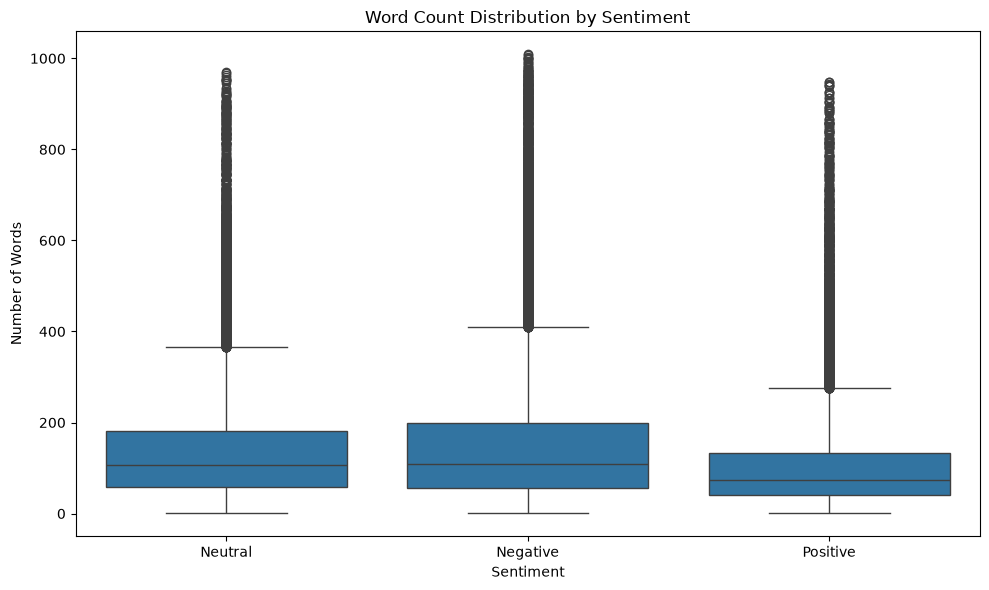

In [63]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count"
)

plt.title("Word Count Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.tight_layout()

plt.savefig(
    "../images/word_count_by_sentiment.png",
    dpi=300
)

plt.show()

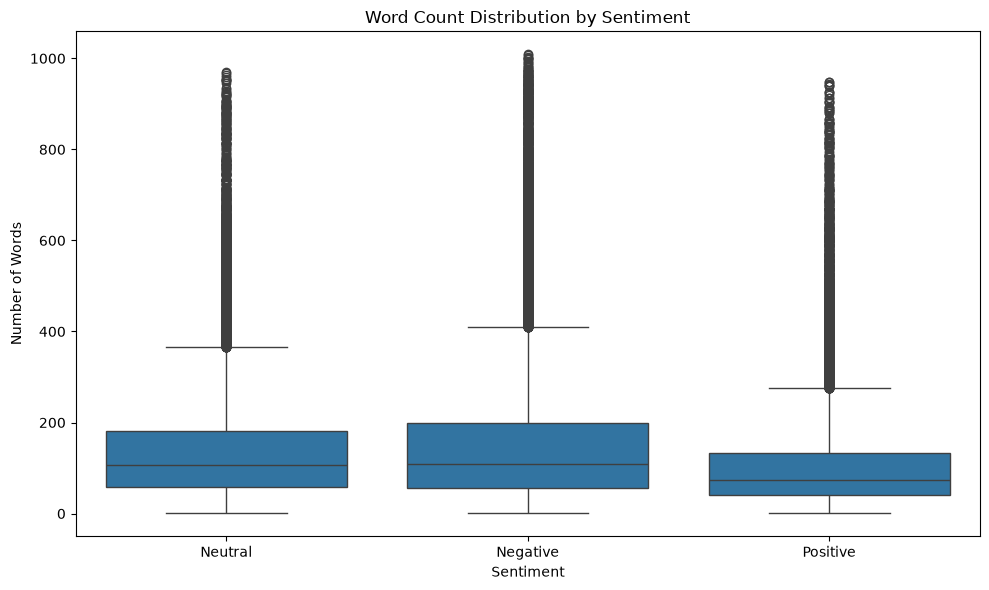

In [64]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count"
)

plt.title("Word Count Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.tight_layout()

plt.savefig(
    "../images/word_count_by_sentiment.png",
    dpi=300
)

plt.show()

In [65]:
# Load English stopwords from NLTK.

stop_words = set(
    stopwords.words("english")
)

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


In [66]:
# Negation words are important for sentiment classification.
# We remove them from the stopword list so that words such as
# "not", "no", and "never" are preserved during preprocessing.

negation_words = {
    "no",
    "not",
    "never",
    "neither",
    "nor",
    "none",
    "nobody",
    "nothing",
    "nowhere",
    "hardly",
    "barely",
    "scarcely"
}

stop_words = stop_words - negation_words

print("Negation words preserved:", negation_words)

Negation words preserved: {'nor', 'no', 'none', 'nowhere', 'nobody', 'hardly', 'neither', 'barely', 'scarcely', 'nothing', 'not', 'never'}


In [67]:
def handle_negation(tokens):
    """
    Combine a negation word with the word immediately following it.

    Example:
    ["food", "was", "not", "good"]
    becomes:
    ["food", "was", "not_good"]

    This helps preserve sentiment information that could otherwise
    be lost when stopwords are removed.
    """

    negation_words = {
        "no",
        "not",
        "never",
        "neither",
        "nor",
        "none",
        "nobody",
        "nothing",
        "nowhere",
        "hardly",
        "barely",
        "scarcely"
    }

    result = []

    i = 0

    while i < len(tokens):

        if (
            tokens[i] in negation_words
            and i + 1 < len(tokens)
        ):
            result.append(
                tokens[i] + "_" + tokens[i + 1]
            )

            i += 2

        else:
            result.append(tokens[i])

            i += 1

    return result

## Stemming vs Lemmatization

Both stemming and lemmatization reduce words to their base forms.

Stemming uses simple rules to remove word endings and can sometimes produce
non-dictionary words. Lemmatization uses linguistic information to return
a meaningful base form.

In this project, both methods are demonstrated for learning purposes.
Lemmatization is selected for the final preprocessing pipeline because
it generally produces more meaningful word forms.

In [68]:
# STEMMING EXAMPLE
# This section is included to demonstrate stemming.
# Stemming will NOT be used in the final preprocessing pipeline.

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

example_words = [
    "liked",
    "loving",
    "studies",
    "running",
    "easily",
    "better"
]

stemmed_words = [
    stemmer.stem(word)
    for word in example_words
]

stemming_comparison = pd.DataFrame({
    "Original Word": example_words,
    "Stemmed Word": stemmed_words
})

stemming_comparison

,Original Word,Stemmed Word
0,liked,like
1,loving,love
2,studies,studi
3,running,run
4,easily,easili
5,better,better


In [69]:
# LEMMATIZATION EXAMPLE
# Lemmatization attempts to convert words into meaningful base forms.

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in example_words
]

lemmatization_comparison = pd.DataFrame({
    "Original Word": example_words,
    "Lemmatized Word": lemmatized_words
})

lemmatization_comparison

,Original Word,Lemmatized Word
0,liked,liked
1,loving,loving
2,studies,study
3,running,running
4,easily,easily
5,better,better


In [70]:
def lemmatize_tokens(tokens):
    """
    Apply lemmatization to a list of tokens.

    Lemmatization is used in the final preprocessing pipeline.
    """

    return [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]

In [71]:
def preprocess_text(text):
    """
    Clean and preprocess a review for NLP classification.

    Steps:
    1. Convert text to lowercase.
    2. Remove punctuation.
    3. Tokenize the text.
    4. Handle negation.
    5. Remove stopwords.
    6. Apply lemmatization.
    7. Return the cleaned text.

    Stemming is not used in the final pipeline.
    Lemmatization is used instead.
    """

    # Convert text to lowercase.
    text = text.lower()

    # Remove punctuation.
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenize the text.
    tokens = word_tokenize(text)

    # Handle negation before removing stopwords.
    tokens = handle_negation(tokens)

    # Remove stopwords while preserving negation expressions.
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # Apply lemmatization.
    tokens = lemmatize_tokens(tokens)

    # Convert tokens back into a single string.
    return " ".join(tokens)

In [72]:
test_sentences = [
    "The food was good.",
    "The food was not good.",
    "The service was not bad.",
    "I never liked this restaurant.",
    "The food was excellent!"
]

for sentence in test_sentences:
    print("Original:", sentence)
    print("Cleaned :", preprocess_text(sentence))
    print("-" * 60)

Original: The food was good.
Cleaned : food good
------------------------------------------------------------
Original: The food was not good.
Cleaned : food not_good
------------------------------------------------------------
Original: The service was not bad.
Cleaned : service not_bad
------------------------------------------------------------
Original: I never liked this restaurant.
Cleaned : never_liked restaurant
------------------------------------------------------------
Original: The food was excellent!
Cleaned : food excellent
------------------------------------------------------------


In [73]:
# Apply the preprocessing function to every review.

df["cleaned_text"] = df["review_text"].apply(
    preprocess_text
)

df[
    [
        "review_text",
        "cleaned_text",
        "sentiment"
    ]
].head(10)

,review_text,cleaned_text,sentiment
0,"Suprisingly decent, nothing spectacular but pr...",suprisingly decent nothing_spectacular price o...,Neutral
1,I dont wish to be a KILLJOY...but I wanted to ...,dont wish killjoybut wanted write word warning...,Negative
2,Do yourself a favor and go try this place. You...,favor go try place would never_imagine food he...,Positive
3,As the reviews of Casbah appear to be particul...,review casbah appear particularly longwinded p...,Positive
4,Ah Golden Wok...this place has never dissapoin...,ah golden wokthis place never_dissapointed nng...,Positive
5,The three stars are all for the beer. I have ...,three star beer share four peak beer always li...,Neutral
6,Literally terrible. Enough said.\n*Can't get a...,literally terrible enough saidncant get refill...,Negative
7,Best seafood restaurant in Vegas? My halliBUTT!!,best seafood restaurant vega hallibutt,Negative
8,It's fun to watch them to do tricks but the fo...,fun watch trick food taste pretty blend nothin...,Neutral
9,The good news is: The food at The Orange Table...,good news food orange table great bad news ser...,Neutral


In [74]:
comparison = df[
    [
        "review_text",
        "cleaned_text",
        "sentiment"
    ]
].sample(
    10,
    random_state=42
)

comparison

,review_text,cleaned_text,sentiment
59770,This is summary of an email I sent to the mana...,summary email sent manager regarding quality c...,Negative
21362,When I visited Pittsburgh first thing I did wa...,visited pittsburgh first thing visit strip dis...,Neutral
127324,was seated quickly. prompt service. Had brea...,seated quickly prompt service breakfast yelper...,Neutral
140509,The convention center is quite nice. I find i...,convention center quite nice find easy navigat...,Neutral
144297,Ods limos do not have A/C in their limos. Bewa...,od limo not_have ac limo beware booking la veg...,Negative
96370,"Unlike most places, this place is NOT stingy o...",unlike place place not_stingy topping love got...,Positive
49742,"Heads up people, from what we heard, this wond...",head people heard wonderful place closed withi...,Positive
47389,Kudos for bringing sunshine and great coffee f...,kudos bringing sunshine great coffee big wash ...,Positive
58378,"Wow! The bell hop said we couldnt use a cart, ...",wow bell hop said couldnt use cart like proper...,Negative
69047,Our water softener bit the dust. It was includ...,water softener bit dust included sale bought h...,Positive


In [75]:
# Check whether any reviews became empty after preprocessing.

empty_reviews = (
    df["cleaned_text"]
    .str.strip()
    .eq("")
    .sum()
)

print("Number of empty cleaned reviews:", empty_reviews)


Number of empty cleaned reviews: 12


In [79]:
# Check for both missing values (NaN) and empty strings
# in the cleaned text column.

missing_cleaned_text = df["cleaned_text"].isna().sum()

empty_cleaned_text = (
    df["cleaned_text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Missing cleaned_text values:", missing_cleaned_text)
print("Empty cleaned_text values:", empty_cleaned_text)

Missing cleaned_text values: 0
Empty cleaned_text values: 12


In [80]:
# Identify reviews that became empty after preprocessing.

empty_mask = (
    df["cleaned_text"]
    .fillna("")
    .str.strip()
    .eq("")
)

empty_reviews = df[empty_mask]

print("Number of empty cleaned reviews:", len(empty_reviews))

print("\nEmpty reviews by sentiment:")
print(empty_reviews["sentiment"].value_counts())

print("\nEmpty reviews:")
print(
    empty_reviews[
        ["review_text", "sentiment", "cleaned_text"]
    ]
)

Number of empty cleaned reviews: 12

Empty reviews by sentiment:
sentiment
Negative    8
Positive    3
Neutral     1
Name: count, dtype: int64

Empty reviews:
       review_text sentiment cleaned_text
16801        .....  Negative             
49100            A  Negative             
52720          :-(  Negative             
55090        So so   Neutral             
56128           ;)  Positive             
66888          : (  Negative             
77126          The  Negative             
83069           ..  Positive             
92572            T  Negative             
116569         :-)  Positive             
122537         THE  Negative             
143480           .  Negative             


In [81]:
# Remove reviews that contain no usable text after preprocessing.

df = df[
    ~empty_mask
].reset_index(drop=True)

print("Dataset shape after removing empty reviews:")
print(df.shape)

print("\nClass distribution after removing empty reviews:")
print(df["sentiment"].value_counts())

Dataset shape after removing empty reviews:
(149988, 6)

Class distribution after removing empty reviews:
sentiment
Neutral     49999
Positive    49997
Negative    49992
Name: count, dtype: int64


In [82]:
# Restore exactly 50,000 valid reviews for each sentiment class.
# Additional reviews are sampled from the same sentiment class
# to maintain the required class balance.

target_per_class = 50000

balanced_data = []

for sentiment_class in ["Negative", "Neutral", "Positive"]:

    class_data = df[
        df["sentiment"] == sentiment_class
    ].copy()

    current_count = len(class_data)

    if current_count < target_per_class:

        additional_rows = class_data.sample(
            n=target_per_class - current_count,
            random_state=42
        )

        class_data = pd.concat(
            [
                class_data,
                additional_rows
            ],
            ignore_index=True
        )

    balanced_data.append(class_data)


# Combine all three sentiment classes.
df = pd.concat(
    balanced_data,
    ignore_index=True
)


# Shuffle the final dataset.
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


print("Final dataset shape:")
print(df.shape)

print("\nFinal sentiment distribution:")
print(df["sentiment"].value_counts())

Final dataset shape:
(150000, 6)

Final sentiment distribution:
sentiment
Neutral     50000
Negative    50000
Positive    50000
Name: count, dtype: int64


In [84]:
# Final validation before saving the processed dataset.

print("Final dataset shape:")
print(df.shape)

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())


# Check for empty cleaned text.
empty_cleaned_text = (
    df["cleaned_text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print(
    "\nEmpty cleaned_text values:",
    empty_cleaned_text
)



Final dataset shape:
(150000, 6)

Sentiment distribution:
sentiment
Neutral     50000
Negative    50000
Positive    50000
Name: count, dtype: int64

Missing values:
class_index      0
review_text      0
sentiment        0
review_length    0
word_count       0
cleaned_text     0
dtype: int64

Empty cleaned_text values: 0


In [85]:
output_path = (
    "../data/processed/"
    "yelp_balanced_150k_cleaned.csv"
)

df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print("Location:", output_path)

Cleaned dataset saved successfully.
Location: ../data/processed/yelp_balanced_150k_cleaned.csv
